# Detección y Clasificación de Retinopatía Diabética con Deep Learning

## 0. Antes de empezar: Entorno Virtual (venv)
1. `python -m venv .venv`
2. `./.venv/Scripts/activate.ps1` (Windows) o `source .venv/bin/activate` (Linux/Mac)

## 1. Configuración del Entorno de Trabajo
En primer lugar, es necesario preparar el entorno e instalar las dependencias. Utilizaremos **PyTorch** como framework principal, ya que es el estándar actual en investigación de visión artificial y ofrece gran flexibilidad.

Dado que mi equipo cuenta con una tarjeta gráfica Intel ARC, he configurado una versión optimizada de PyTorch que soporta de forma nativa la arquitectura de Intel (XPU). El resto de librerías para procesar los datos y visualizar las gráficas se encuentran en el archivo `requirements.txt`.

In [1]:
# 1. Instalación de las herramientas básicas para manipular datos y crear visualizaciones
# %pip install -r requirements.txt

In [2]:
# 2. Descarga de la versión de PyTorch específica para tarjetas Intel ARC
# %pip install torch torchvision --index-url https://download.pytorch.org/whl/xpu

Importamos las librerías principales. Si no se produce ningún error, significa que la instalación ha sido exitosa y el entorno está listo para trabajar.

In [3]:
import os
import glob
import time
import random
import copy
import cv2
import shutil
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
import torchvision.models as models

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick


from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
)

print("[INFO] Librerías cargadas correctamente.")

[INFO] Librerías cargadas correctamente.


### 1.1. Activando la Tarjeta Gráfica (XPU / GPU) y Fijando las Semillas de Aleatoriedad

Como se ha instalado antes el PyTorch modificado, el sistema debería detectar la XPU directamente.

Fijamos semillas globales (`SEMILLA = 42`) en todas las librerías de aleatoriedad (Python, NumPy y PyTorch). Esto garantiza que los resultados sean **100% reproducibles**: cada vez que se ejecuta el notebook completo desde cero, los splits de datos, la inicialización de pesos y el orden de los lotes serán exactamente los mismos. Sin esto, cada ejecución puede dar resultados ligeramente distintos.

In [4]:
SEMILLA = 42
random.seed(SEMILLA)
np.random.seed(SEMILLA)
torch.manual_seed(SEMILLA)

# Si el código se despliega en otra máquina distinta a mi Intel ARC:
# - Dispositivos NVIDIA: Cambiar 'xpu' por 'cuda'
# - Dispositivos Mac (M1/M2/M3): Cambiar 'xpu' por 'mps'

if hasattr(torch, "xpu") and torch.xpu.is_available():
    device = torch.device("xpu")
    nombre_grafica = torch.xpu.get_device_name(0)
    print(f"[INFO] Gráfica Intel detectada con éxito. Modelo: {nombre_grafica}")
    torch.xpu.manual_seed(SEMILLA)
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"[INFO] GPU NVIDIA detectada: {torch.cuda.get_device_name(0)}")
    torch.cuda.manual_seed_all(SEMILLA)
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print("[INFO] GPU Apple Silicon detectada")
    torch.manual_seed(SEMILLA)
else:
    device = torch.device("cpu")
    print("[AVISO] No se detectó GPU. Se utilizará la CPU (entrenamiento lento).")

print("-" * 60)
print(f"Todo el procesamiento del proyecto se enviará a: {device}")
print(f"Semilla de aleatoriedad fijada a: {SEMILLA}")
print("-" * 60)

[INFO] GPU Apple Silicon detectada
------------------------------------------------------------
Todo el procesamiento del proyecto se enviará a: mps
Semilla de aleatoriedad fijada a: 42
------------------------------------------------------------


## 2. Preparación de los Datos

Antes de entrenar las redes neuronales, tenemos que preparar el formato de las imágenes. Como en esta **Fase 1** del proyecto nuestro objetivo es simplemente distinguir entre un paciente Sano y uno Enfermo, vamos a convertir el problema original (que tiene 5 niveles de gravedad) en uno de clasificación binaria.

Las imágenes con etiqueta `0-noDR` representarán la clase "Sano" (0). El resto de imágenes (desde `1-mild` hasta `4-proliferative`) las voy a agrupar en una sola gran clase que llamaremos "Enfermo" (1).

### 2.1. Variables Globales
Para mantener el código estructurado desde el principio, voy a centralizar las configuraciones principales en estas variables.

* **`RUTA_DATOS`**: La carpeta raíz donde tengo guardadas las imágenes.
* **`IMG_SIZE`**: Establecido en `224`. Es el tamaño exacto que requieren modelos como VGG16 y ResNet como entrada.
* **`MEAN_RGB` y `STD_RGB`**: Corresponden a los valores medios y la desviación de color de la base ImageNet. Es obligatorio aplicarlos para estabilizar matemáticamente el Transfer Learning.
* **`BATCH_SIZE`**: Le indica a la red cuántas fotos a la vez debe procesar la GPU sin quedarse sin memoria.
* **`NUM_CLASES`**: La cantidad de clases entre las que vamos a distinguir.

In [5]:
RUTA_DATOS_TRAIN = r"fotos_raw_train"
RUTA_DATOS_TEST  = r"fotos_raw_test"
RUTA_DATOS = RUTA_DATOS_TRAIN  # Se mantiene para celdas de visualizacion rapida
IMG_SIZE = 224

# Normalizacion estandar para Transfer Learning con ImageNet
MEAN_RGB = [0.485, 0.456, 0.406]
STD_RGB = [0.229, 0.224, 0.225]

BATCH_SIZE = 32
NUM_CLASES = 2
LEARNING_RATE = 0.0003

# Fase 1 (pruebas rapidas): usar solo fotos_raw_test y partir en train/test
FRACCION_TRAIN_FASE1 = 0.8

### 2.2. Transformación de las Imágenes (Preprocesado básico)

Para que la red pueda leer correctamente las fotografías, necesitamos aplicarle unos pasos obligatorios:
1. **Resize:** Reescalamos todas y cada una de las imágenes al tamaño estándar de `224x224` píxeles.
2. **ToTensor:** Convierte la imagen original de su formato (RGB) a una matriz matemática de PyTorch (un Tensor).
3. **Normalize:** Ajusta el balance de los canales de color utilizando los factores globales de ImageNet.

In [6]:
# Las transformaciones mínimas obligatorias para la evaluación (Test siempre limpio)
transformaciones_base = transforms.Compose(
    [
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=MEAN_RGB, std=STD_RGB),
    ]
)

### 2.3. Visualizando el efecto de las transformaciones

A continuación, vamos a ver visualmente el impacto del proceso programado sobre las fotos de nuestras retinas. A la izquierda se ve la original y a la derecha cómo la recibirá internamente la IA en la red.

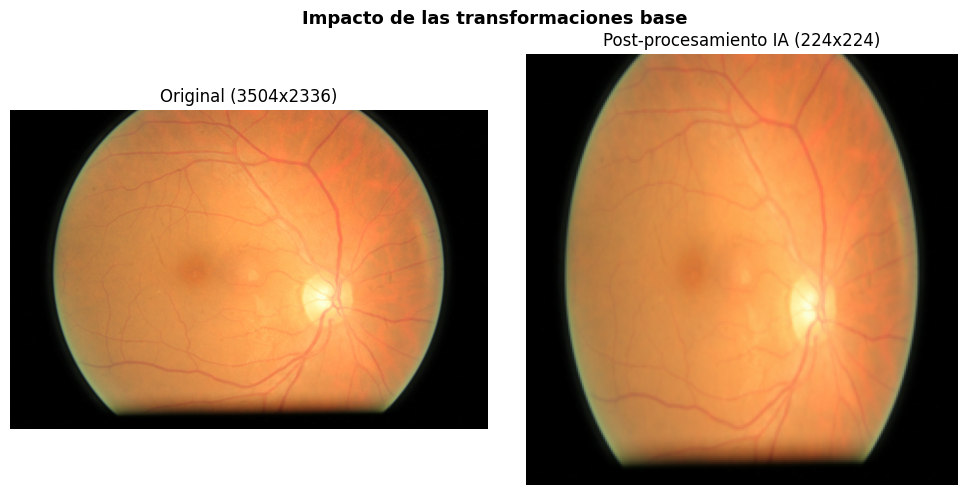

In [7]:
# Seleccionamos una imagen aleatoria desde los directorios del proyecto
todas_las_fotos = glob.glob(f"{RUTA_DATOS}/*/*.*")
ruta_foto = random.choice(todas_las_fotos)
foto_original = Image.open(ruta_foto)

# Aplicamos las transformaciones y desnormalizamos para visualizar
foto_ia = transformaciones_base(foto_original)
foto_dibujable = foto_ia.permute(1, 2, 0).numpy()  # type: ignore
foto_dibujable = np.clip(foto_dibujable * np.array(STD_RGB) + np.array(MEAN_RGB), 0, 1)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].imshow(foto_original)
axs[0].set_title(f"Original ({foto_original.size[0]}x{foto_original.size[1]})")
axs[0].axis("off")
axs[1].imshow(foto_dibujable)
axs[1].set_title(f"Post-procesamiento IA ({IMG_SIZE}x{IMG_SIZE})")
axs[1].axis("off")
plt.suptitle("Impacto de las transformaciones base", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

### 2.4. Carga de Directorios y Cambio de Clases

Voy a usar `ImageFolder` para cargar toda la carpeta. Aprovecharé también este momento de carga para decirle a PyTorch que aplique el filtro binario dinámicamente frente a las carpetas originales:
Si el archivo proviene de la subcarpeta Sano (0), lo deja intactamente etiquetado como `0`. Y si procede de los diversos grados de patología, los reescribe todos como `1` (Enfermo).

In [8]:
# [FASE 1 RAPIDA] Usar solo fotos_raw_test y dividir en train/test
dataset_base_fase1 = datasets.ImageFolder(
    root=RUTA_DATOS_TEST,
    transform=transformaciones_base,
    target_transform=lambda c: 0 if c == 0 else 1,
)

total_fase1 = len(dataset_base_fase1)
n_train = int(FRACCION_TRAIN_FASE1 * total_fase1)
n_test = total_fase1 - n_train

gen_split = torch.Generator().manual_seed(SEMILLA)
dataset_train_raw, dataset_test_raw = random_split(
    dataset_base_fase1, [n_train, n_test], generator=gen_split
)

print("[INFO] Fase 1 en modo rápido (solo fotos_raw_test)")
print(f"       Base usada: {RUTA_DATOS_TEST}")
print(f"       Split train/test: {n_train}/{n_test} ({FRACCION_TRAIN_FASE1:.0%}/{1-FRACCION_TRAIN_FASE1:.0%})")

[INFO] Fase 1 en modo rápido (solo fotos_raw_test)
       Base usada: fotos_raw_test
       Split train/test: 972/244 (80%/20%)


### 2.5. Verificación del Dataset para Fase 1 (prueba rápida)

Para esta fase de comparativa rápida, usaremos solo `fotos_raw_test` y haremos un split reproducible en train/test con `random_split`.

Más adelante, en la validación completa del proyecto, volveremos al esquema completo con carpetas separadas.

In [9]:
# Conteo y verificacion del split rapido de Fase 1
train_imagenes = len(dataset_train_raw)
test_imagenes = len(dataset_test_raw)
total_imagenes = train_imagenes + test_imagenes

print("[INFO] Split rapido Fase 1:")
print(f"       Train : {train_imagenes} imagenes")
print(f"       Test  : {test_imagenes} imagenes")
print(f"       Total : {total_imagenes} imagenes")

[INFO] Split rapido Fase 1:
       Train : 972 imagenes
       Test  : 244 imagenes
       Total : 1216 imagenes


### 2.6. Configuración de Minibatches (DataLoaders)

Finalmente necesitamos empaquetar estos conjuntos en instancias `DataLoader`. No se puede intentar subir miles de imágenes HD hacia la gráfica de golpe; los dataloaders ayudan a organizarlo enviándole porciones constantes.

In [10]:
loader_train = DataLoader(dataset_train_raw, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
loader_test = DataLoader(dataset_test_raw, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

# Verificacion rapida de que los datos tienen el formato correcto
fotos_bloque, respuestas_bloque = next(iter(loader_train))
print(f"[OK] Dimensiones de un lote: {fotos_bloque.shape}  ->  [batch, canales, alto, ancho]")
print(f"[OK] Ejemplo de etiquetas binarias: \n{respuestas_bloque}")

[OK] Dimensiones de un lote: torch.Size([32, 3, 224, 224])  ->  [batch, canales, alto, ancho]
[OK] Ejemplo de etiquetas binarias: 
tensor([1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1,
        1, 1, 1, 0, 0, 1, 1, 1])


## 3. Fase 1: Entrenamiento y Comparativa de Modelos (Clasificación Binaria)

### 3.1. Primer modelo de prueba: VGG16

Para empezar el estudio voy a usar **VGG16**. Se considera una de las arquitecturas clásicas más conocidas. Es más pesada y más lenta, pero sirve como línea base de referencia.

#### Adaptando el clasificador a nuestro caso concreto

VGG16 está pre-entrenada con ImageNet. Necesitamos:
1. **Congelar su aprendizaje central (`requires_grad = False`)**: se deja su estructura detectora intacta.
2. **Reemplazar la capa clasificatoria final**: de 1.000 clases a las 2 que necesitamos.

In [11]:
modelo_vgg = models.vgg16(weights=models.VGG16_Weights.DEFAULT)
print("[INFO] Estructura original de la capa de clasificación final en VGG16:")
print(modelo_vgg.classifier)

[INFO] Estructura original de la capa de clasificación final en VGG16:
Sequential(
  (0): Linear(in_features=25088, out_features=4096, bias=True)
  (1): ReLU(inplace=True)
  (2): Dropout(p=0.5, inplace=False)
  (3): Linear(in_features=4096, out_features=4096, bias=True)
  (4): ReLU(inplace=True)
  (5): Dropout(p=0.5, inplace=False)
  (6): Linear(in_features=4096, out_features=1000, bias=True)
)


Concretamente `(6): Linear(in_features=4096, out_features=1000)` nos demuestra que la red quiere emitir 1.000 clases. Por lo tanto congelo su memoria de reconocimiento y redefinimos solo esa capa `[6]` para nuestra FASE 1:

In [12]:
for parametro in modelo_vgg.parameters():
    parametro.requires_grad = False

neuronas_entrada = modelo_vgg.classifier[6].in_features
modelo_vgg.classifier[6] = nn.Linear(neuronas_entrada, NUM_CLASES) # type: ignore
modelo_vgg = modelo_vgg.to(device)

optimizador_vgg = optim.Adam(modelo_vgg.classifier[6].parameters(), lr=LEARNING_RATE)

print(f"[OK] VGG16 preparado para {NUM_CLASES} clases.")
print(f"     Capa final: {modelo_vgg.classifier[6]}")

[OK] VGG16 preparado para 2 clases.
     Capa final: Linear(in_features=4096, out_features=2, bias=True)


### 3.2. Segundo modelo a examinar: ResNet50

Como alternativa a VGG16, voy a usar **ResNet50**. Su principal ventaja es que soluciona el problema del "desvanecimiento del gradiente" introduciendo conexiones residuales (saltos entre capas). En ResNet50, la capa final se llama `.fc` (Fully Connected).

In [13]:
modelo_resnet = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
print("[INFO] Estructura original de la capa de clasificación final en ResNet50:")
print(modelo_resnet.fc)
print("-" * 60)

for parametro in modelo_resnet.parameters():
    parametro.requires_grad = False

neuronas_entrada   = modelo_resnet.fc.in_features
modelo_resnet.fc   = nn.Linear(neuronas_entrada, NUM_CLASES)
modelo_resnet      = modelo_resnet.to(device)
optimizador_resnet = optim.Adam(modelo_resnet.fc.parameters(), lr=LEARNING_RATE)

print(f"[OK] ResNet50 preparado para {NUM_CLASES} clases.")
print(f"     Capa final: {modelo_resnet.fc}")

[INFO] Estructura original de la capa de clasificación final en ResNet50:
Linear(in_features=2048, out_features=1000, bias=True)
------------------------------------------------------------
[OK] ResNet50 preparado para 2 clases.
     Capa final: Linear(in_features=2048, out_features=2, bias=True)


### 3.3. Tercer modelo a examinar: EfficientNet-B0

Para la última prueba he elegido **EfficientNet-B0**, que es un modelo mucho más moderno y optimizado. En lugar de añadir más capas a lo bruto, esta red escala de forma equilibrada la profundidad, anchura y resolución. Suele dar muy buenos resultados en imágenes médicas con menor coste computacional. La capa final se llama `.classifier[1]`.

In [14]:
modelo_eff = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)
print("[INFO] Estructura original de la capa final en EfficientNet-B0:")
print(modelo_eff.classifier)
print("-" * 60)

for parametro in modelo_eff.parameters():
    parametro.requires_grad = False

neuronas_entrada = modelo_eff.classifier[1].in_features
modelo_eff.classifier[1] = nn.Linear(neuronas_entrada, NUM_CLASES) # type: ignore
modelo_eff = modelo_eff.to(device)
optimizador_eff = optim.Adam(modelo_eff.classifier[1].parameters(), lr=LEARNING_RATE)

print(f"[OK] EfficientNet-B0 preparado para {NUM_CLASES} clases.")
print(f"     Capa final: {modelo_eff.classifier[1]}")

[INFO] Estructura original de la capa final en EfficientNet-B0:
Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)
------------------------------------------------------------
[OK] EfficientNet-B0 preparado para 2 clases.
     Capa final: Linear(in_features=1280, out_features=2, bias=True)


### 3.4. Motor de Entrenamiento y Evaluación

Aquí se encuentra el núcleo del proyecto. Se definen tres elementos fundamentales:

1. **`DatasetConTransform`** — clase auxiliar que permite aplicar transformaciones distintas a Train y Test *después* del split, evitando el Data Leakage (que las rotaciones de augmentation contaminen el conjunto de evaluación).

2. **Funciones de entrenamiento y evaluación** — modulares y reutilizables en todas las fases.

3. **`entrenar_modelo()`** — función que incluye Early Stopping y Learning Rate Scheduler.

In [15]:
# ==========================================
# 1. Clase auxiliar para transforms por subconjunto
# ==========================================
class DatasetConTransform(torch.utils.data.Dataset):
    """
    Permite aplicar transformaciones diferentes a Train y Test
    sobre un mismo dataset base ya dividido con random_split.
    Esto es fundamental para no contaminar Test con Data Augmentation.
    """

    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __getitem__(self, index):
        x, y = self.subset[index]
        if self.transform:
            x = self.transform(x)
        return x, y

    def __len__(self):
        return len(self.subset)


# ==========================================
# 2. Fase de entrenamiento (una época)
# ==========================================
def ejecutar_fase_train(modelo, loader_train, criterion, optimizer, device):
    """Ejecuta una época completa de entrenamiento y devuelve loss y accuracy medios."""
    modelo.train()
    perdida_total = 0.0
    aciertos_total = 0
    total_lotes = len(loader_train)

    for i, (imagenes, etiquetas) in enumerate(loader_train):
        imagenes = imagenes.to(device)
        etiquetas = etiquetas.to(device)

        optimizer.zero_grad()
        predicciones = modelo(imagenes)
        loss = criterion(predicciones, etiquetas)
        loss.backward()
        optimizer.step()

        _, clase_elegida = torch.max(predicciones, 1)
        perdida_total += loss.item() * imagenes.size(0)
        aciertos_total += torch.sum(clase_elegida == etiquetas.data)

        if (i + 1) % 5 == 0 or (i + 1) == total_lotes:
            print(
                f"   [>] Lote {i+1}/{total_lotes} ({imagenes.size(0)} imgs) | Loss: {loss.item():.4f}"
            )

    media_loss = perdida_total / len(loader_train.dataset)
    media_acc = aciertos_total.float() / len(loader_train.dataset)  # type: ignore
    return float(media_loss), float(media_acc)


# ==========================================
# 3. Fase de evaluación (una época)
# ==========================================
def ejecutar_fase_evaluacion(modelo, loader_test, criterion, device):
    """Ejecuta una época completa de evaluación (Test) y devuelve loss y accuracy medios."""
    modelo.eval()
    perdida_total = 0.0
    aciertos_total = 0
    total_lotes = len(loader_test)

    with torch.no_grad():
        for i, (imagenes, etiquetas) in enumerate(loader_test):
            imagenes = imagenes.to(device)
            etiquetas = etiquetas.to(device)

            predicciones = modelo(imagenes)
            loss = criterion(predicciones, etiquetas)
            _, clase_elegida = torch.max(predicciones, 1)

            perdida_total += loss.item() * imagenes.size(0)
            aciertos_total += torch.sum(clase_elegida == etiquetas.data)

            if (i + 1) % 5 == 0 or (i + 1) == total_lotes:
                print(f"   [>] Evaluando lote {i+1}/{total_lotes} ({imagenes.size(0)} imgs)...")

    media_loss = perdida_total / len(loader_test.dataset)
    media_acc = aciertos_total.float() / len(loader_test.dataset)  # type: ignore
    return float(media_loss), float(media_acc)


# ==========================================
# 4. Función orquestadora del bucle completo
# ==========================================
def entrenar_modelo(
    modelo,
    loader_train,
    loader_test,
    criterion,
    optimizer,
    num_epocas=10,
    scheduler=None,
    patience=3,
):
    """
    Entrena el modelo durante num_epocas con Early Stopping y Scheduler.
    Devuelve el modelo con los mejores pesos y un historial completo de 4 métricas.
    """
    print(f"[INFO] Iniciando entrenamiento: {num_epocas} épocas | Paciencia ES: {patience}\n")

    historial = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    mejor_loss_test = float("inf")
    epocas_sin_mejora = 0
    mejores_pesos = copy.deepcopy(modelo.state_dict())

    for epoca in range(num_epocas):
        inicio_tiempo = time.time()
        print(f"{'='*50}\n[INFO] ÉPOCA {epoca+1} de {num_epocas}\n{'='*50}")

        # TRAIN
        print(f"[TRAIN] Procesando {len(loader_train)} lotes...")
        loss_train, acc_train = ejecutar_fase_train(
            modelo, loader_train, criterion, optimizer, device
        )
        print(f"   [RESULTADO TRAIN] Acc: {acc_train:.4f} | Loss: {loss_train:.4f}\n")

        # TEST
        print("[TEST] Evaluando sobre el conjunto de pruebas...")
        loss_test, acc_test = ejecutar_fase_evaluacion(modelo, loader_test, criterion, device)
        print(f"   [RESULTADO TEST]  Acc: {acc_test:.4f} | Loss: {loss_test:.4f}")

        # Registrar todas las métricas
        historial["train_loss"].append(loss_train)
        historial["train_acc"].append(acc_train)
        historial["test_loss"].append(loss_test)
        historial["test_acc"].append(acc_test)

        # Scheduler
        if scheduler is not None:
            if isinstance(scheduler, torch.optim.lr_scheduler.ReduceLROnPlateau):
                scheduler.step(loss_test)
            else:
                scheduler.step()
            lr_actual = optimizer.param_groups[0]["lr"]
            print(f"   [SCHEDULER] Learning Rate: {lr_actual:.6f}")

        # Early Stopping
        if loss_test < mejor_loss_test:
            mejor_loss_test = loss_test
            epocas_sin_mejora = 0
            mejores_pesos = copy.deepcopy(modelo.state_dict())
            print("   [OK] Nuevo mejor modelo guardado.")
        else:
            epocas_sin_mejora += 1
            print(f"   [AVISO] Sin mejora. Early Stopping: {epocas_sin_mejora}/{patience}")

        print(f"[INFO] Tiempo época {epoca+1}: {time.time() - inicio_tiempo:.0f}s\n")

        if epocas_sin_mejora >= patience:
            print(f"[ALERTA] Early Stopping activado en época {epoca+1}.")
            break

    modelo.load_state_dict(mejores_pesos)
    print("[INFO] Entrenamiento concluido. Modelo restaurado con el mejor loss de Test.")
    return modelo, historial

In [16]:
# Función para graficar el historial completo
def graficar_historial(historial, titulo="Evolución del Entrenamiento"):
    """
    [NUEVO] Genera 4 subgráficas: Train Loss, Test Loss, Train Acc, Test Acc.
    Permite detectar overfitting visualmente al ver si Train y Test divergen.
    """
    epocas = range(1, len(historial['train_loss']) + 1)

    fig, axs = plt.subplots(1, 2, figsize=(14, 5))

    # --- Gráfica de Loss ---
    axs[0].plot(epocas, historial['train_loss'], 'o-', label='Train Loss', color='steelblue')
    axs[0].plot(epocas, historial['test_loss'],  's--', label='Test Loss',  color='coral')
    axs[0].set_title("Evolución del Error (Loss)")
    axs[0].set_xlabel("Época")
    axs[0].set_ylabel("Loss (Cross-Entropy)")
    axs[0].legend()
    axs[0].grid(True, linestyle='--', alpha=0.5)

    # --- Gráfica de Accuracy ---
    axs[1].plot(epocas, [a*100 for a in historial['train_acc']], 'o-', label='Train Acc', color='steelblue')
    axs[1].plot(epocas, [a*100 for a in historial['test_acc']],  's--', label='Test Acc',  color='coral')
    axs[1].yaxis.set_major_formatter(mtick.PercentFormatter())
    axs[1].set_title("Evolución de la Precisión (Accuracy)")
    axs[1].set_xlabel("Época")
    axs[1].set_ylabel("Accuracy (%)")
    axs[1].legend()
    axs[1].grid(True, linestyle='--', alpha=0.5)

    plt.suptitle(titulo, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

print("[OK] Motor de entrenamiento y funciones auxiliares cargados.")

[OK] Motor de entrenamiento y funciones auxiliares cargados.


### 3.5. Ejecución de las Pruebas de Entrenamiento

Ahora tenemos preparadas nuestras funciones compartidas, lanzamos las 3 pruebas para registrar y comparar resultados.

In [17]:
# ==========================================
# Hiperparámetros compartidos para la Fase de Comparativa
# ==========================================
EPOCAS_PRUEBA = 15
PACIENCIA_EARLY_STOP = 6
PACIENCIA_SCHEDULER = 2

criterio_error = nn.CrossEntropyLoss()

print("[INFO] Configuración Fase 1:")
print(
    f"       Épocas: {EPOCAS_PRUEBA} | Paciencia ES: {PACIENCIA_EARLY_STOP} | Paciencia Scheduler: {PACIENCIA_SCHEDULER}"
)

[INFO] Configuración Fase 1:
       Épocas: 15 | Paciencia ES: 6 | Paciencia Scheduler: 2


In [18]:
# =================================================================
# PRUEBA 1: VGG16
# =================================================================
print("-" * 60)
print("[MODELO 1] Entrenamiento inicial: VGG16")
print("-" * 60)

scheduler_vgg = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_vgg, mode='min', factor=0.5, patience=PACIENCIA_SCHEDULER, min_lr=1e-6)

modelo_vgg = modelo_vgg.to(device)

modelo_vgg, historial_vgg = entrenar_modelo(
    modelo       = modelo_vgg,
    loader_train = loader_train,
    loader_test  = loader_test,
    criterion    = criterio_error,
    optimizer    = optimizador_vgg,
    num_epocas   = EPOCAS_PRUEBA,
    scheduler    = scheduler_vgg,
    patience     = PACIENCIA_EARLY_STOP
)

------------------------------------------------------------
[MODELO 1] Entrenamiento inicial: VGG16
------------------------------------------------------------
[INFO] Iniciando entrenamiento: 15 épocas | Paciencia ES: 6

[INFO] ÉPOCA 1 de 15
[TRAIN] Procesando 31 lotes...
   [>] Lote 5/31 (32 imgs) | Loss: 0.8998
   [>] Lote 10/31 (32 imgs) | Loss: 0.8275
   [>] Lote 15/31 (32 imgs) | Loss: 0.7173
   [>] Lote 20/31 (32 imgs) | Loss: 0.6943
   [>] Lote 25/31 (32 imgs) | Loss: 0.7174
   [>] Lote 30/31 (32 imgs) | Loss: 0.7187
   [>] Lote 31/31 (12 imgs) | Loss: 0.5831
   [RESULTADO TRAIN] Acc: 0.5689 | Loss: 0.7325

[TEST] Evaluando sobre el conjunto de pruebas...
   [>] Evaluando lote 5/8 (32 imgs)...
   [>] Evaluando lote 8/8 (20 imgs)...
   [RESULTADO TEST]  Acc: 0.5779 | Loss: 0.6590
   [SCHEDULER] Learning Rate: 0.000300
   [OK] Nuevo mejor modelo guardado.
[INFO] Tiempo época 1: 39s

[INFO] ÉPOCA 2 de 15
[TRAIN] Procesando 31 lotes...
   [>] Lote 5/31 (32 imgs) | Loss: 0.6514
   

In [19]:
# =================================================================
# PRUEBA 2: ResNet50
# =================================================================
print("-" * 60)
print("[MODELO 2] Entrenamiento inicial: ResNet50")
print("-" * 60)

scheduler_resnet = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_resnet, mode='min', factor=0.5, patience=PACIENCIA_SCHEDULER, min_lr=1e-6)

modelo_resnet, historial_resnet = entrenar_modelo(
    modelo       = modelo_resnet,
    loader_train = loader_train,
    loader_test  = loader_test,
    criterion    = criterio_error,
    optimizer    = optimizador_resnet,
    num_epocas   = EPOCAS_PRUEBA,
    scheduler    = scheduler_resnet,
    patience     = PACIENCIA_EARLY_STOP
)

------------------------------------------------------------
[MODELO 2] Entrenamiento inicial: ResNet50
------------------------------------------------------------
[INFO] Iniciando entrenamiento: 15 épocas | Paciencia ES: 6

[INFO] ÉPOCA 1 de 15
[TRAIN] Procesando 31 lotes...
   [>] Lote 5/31 (32 imgs) | Loss: 0.7598
   [>] Lote 10/31 (32 imgs) | Loss: 0.6619
   [>] Lote 15/31 (32 imgs) | Loss: 0.8110
   [>] Lote 20/31 (32 imgs) | Loss: 0.6242
   [>] Lote 25/31 (32 imgs) | Loss: 0.7576
   [>] Lote 30/31 (32 imgs) | Loss: 0.6486
   [>] Lote 31/31 (12 imgs) | Loss: 0.6461
   [RESULTADO TRAIN] Acc: 0.6039 | Loss: 0.6709

[TEST] Evaluando sobre el conjunto de pruebas...
   [>] Evaluando lote 5/8 (32 imgs)...
   [>] Evaluando lote 8/8 (20 imgs)...
   [RESULTADO TEST]  Acc: 0.6107 | Loss: 0.6542
   [SCHEDULER] Learning Rate: 0.000300
   [OK] Nuevo mejor modelo guardado.
[INFO] Tiempo época 1: 38s

[INFO] ÉPOCA 2 de 15
[TRAIN] Procesando 31 lotes...
   [>] Lote 5/31 (32 imgs) | Loss: 0.6211


In [20]:
# =================================================================
# PRUEBA 3: EfficientNet-B0
# =================================================================
print("-" * 60)
print("[MODELO 3] Entrenamiento inicial: EfficientNet-B0")
print("-" * 60)

scheduler_eff = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_eff, mode='min', factor=0.5, patience=PACIENCIA_SCHEDULER, min_lr=1e-6)

modelo_eff, historial_eff = entrenar_modelo(
    modelo       = modelo_eff,
    loader_train = loader_train,
    loader_test  = loader_test,
    criterion    = criterio_error,
    optimizer    = optimizador_eff,
    num_epocas   = EPOCAS_PRUEBA,
    scheduler    = scheduler_eff,
    patience     = PACIENCIA_EARLY_STOP
)

------------------------------------------------------------
[MODELO 3] Entrenamiento inicial: EfficientNet-B0
------------------------------------------------------------
[INFO] Iniciando entrenamiento: 15 épocas | Paciencia ES: 6

[INFO] ÉPOCA 1 de 15
[TRAIN] Procesando 31 lotes...
   [>] Lote 5/31 (32 imgs) | Loss: 0.6804
   [>] Lote 10/31 (32 imgs) | Loss: 0.6509
   [>] Lote 15/31 (32 imgs) | Loss: 0.6721
   [>] Lote 20/31 (32 imgs) | Loss: 0.6313
   [>] Lote 25/31 (32 imgs) | Loss: 0.6419
   [>] Lote 30/31 (32 imgs) | Loss: 0.6660
   [>] Lote 31/31 (12 imgs) | Loss: 0.5916
   [RESULTADO TRAIN] Acc: 0.5947 | Loss: 0.6734

[TEST] Evaluando sobre el conjunto de pruebas...
   [>] Evaluando lote 5/8 (32 imgs)...
   [>] Evaluando lote 8/8 (20 imgs)...
   [RESULTADO TEST]  Acc: 0.6311 | Loss: 0.6626
   [SCHEDULER] Learning Rate: 0.000300
   [OK] Nuevo mejor modelo guardado.
[INFO] Tiempo época 1: 35s

[INFO] ÉPOCA 2 de 15
[TRAIN] Procesando 31 lotes...
   [>] Lote 5/31 (32 imgs) | Loss: 

### 3.6. Veredicto Final: Elección de la Red Ganadora

Comparamos visualmente los tres modelos. La red ganadora será la que usemos en las siguientes fases.

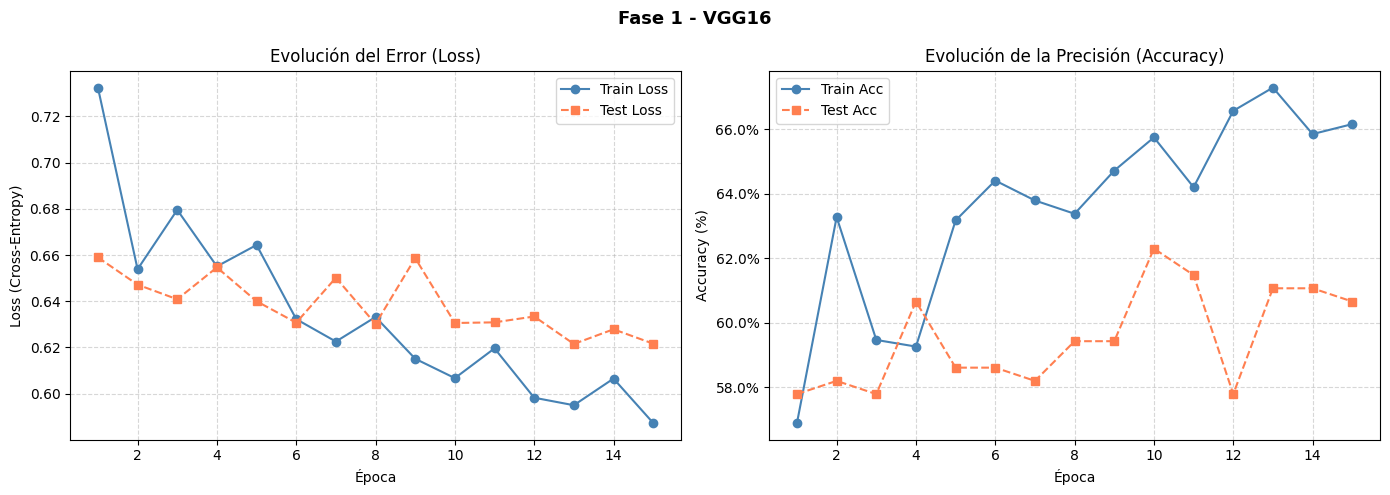

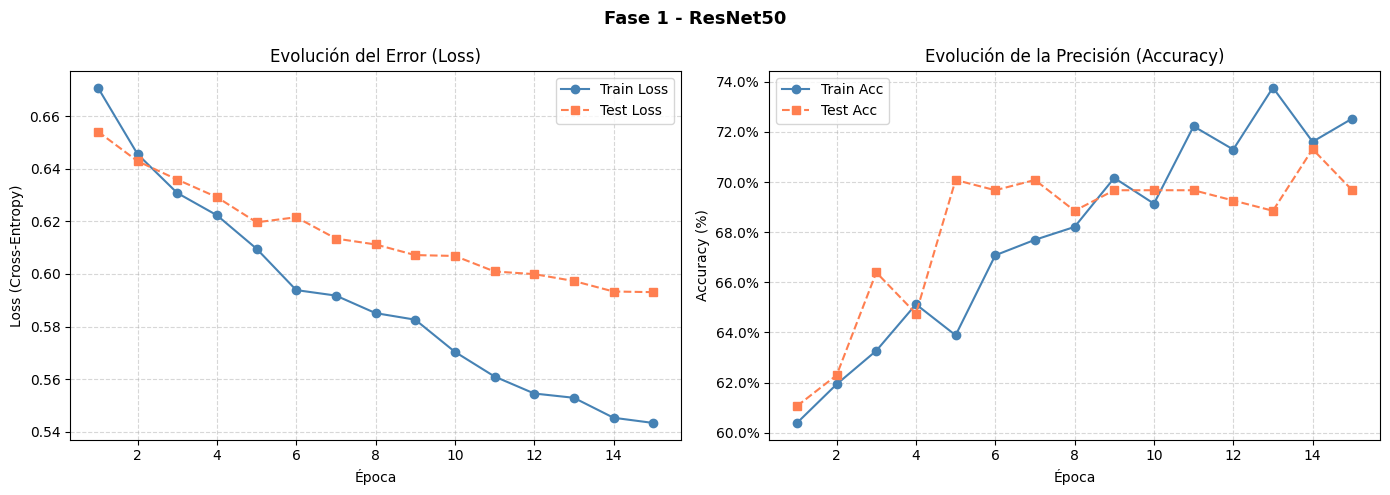

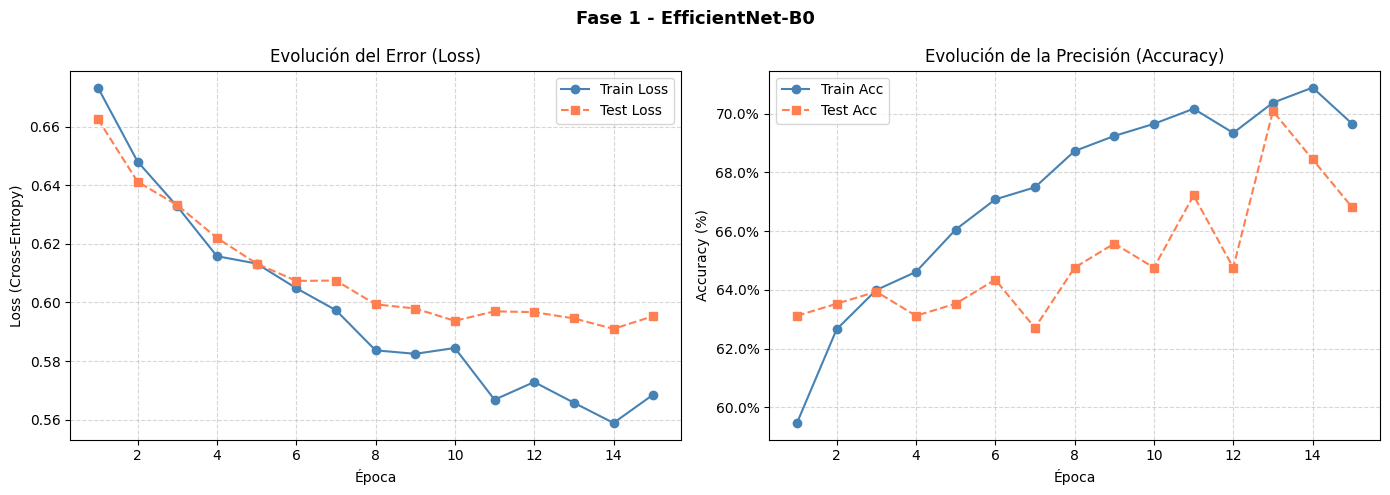

In [21]:
# Graficas individuales (una por modelo)
graficar_historial(historial_vgg, titulo="Fase 1 - VGG16")
graficar_historial(historial_resnet, titulo="Fase 1 - ResNet50")
graficar_historial(historial_eff, titulo="Fase 1 - EfficientNet-B0")


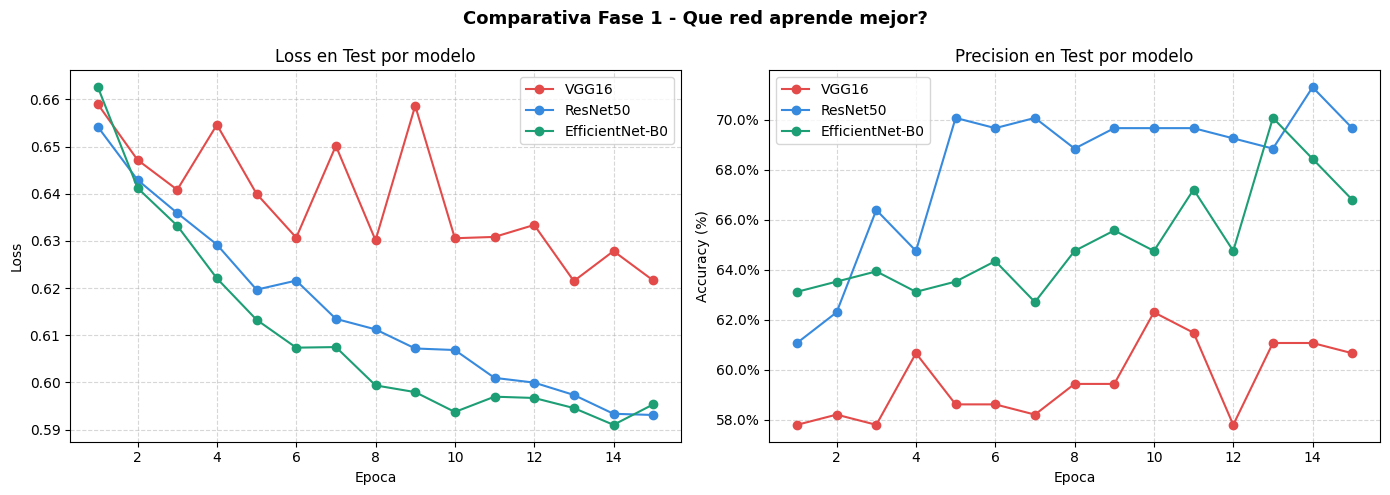


[RESUMEN] Mejor Test Accuracy por modelo:
   VGG16               : 62.30%
   ResNet50            : 71.31%
   EfficientNet-B0     : 70.08%


In [22]:
# Agrupamos los resultados de las 3 redes
evaluacion_comparativa = {
    'VGG16': historial_vgg,
    'ResNet50': historial_resnet,
    'EfficientNet-B0': historial_eff,
}

fig, axs = plt.subplots(1, 2, figsize=(14, 5))
colores = ['#E24B4A', '#378ADD', '#1D9E75']

for (nombre, hist), color in zip(evaluacion_comparativa.items(), colores):
    epocas = range(1, len(hist['test_acc']) + 1)
    axs[0].plot(epocas, hist['test_loss'], 'o-', label=nombre, color=color)
    axs[1].plot(epocas, [a * 100 for a in hist['test_acc']], 'o-', label=nombre, color=color)

axs[0].set_title("Loss en Test por modelo")
axs[0].set_xlabel("Epoca")
axs[0].set_ylabel("Loss")
axs[0].legend()
axs[0].grid(True, linestyle='--', alpha=0.5)

axs[1].set_title("Precision en Test por modelo")
axs[1].set_xlabel("Epoca")
axs[1].set_ylabel("Accuracy (%)")
axs[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axs[1].legend()
axs[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Comparativa Fase 1 - Que red aprende mejor?", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Tabla resumen
print("\n[RESUMEN] Mejor Test Accuracy por modelo:")
for nombre, hist in evaluacion_comparativa.items():
    mejor = max(hist['test_acc'])
    print(f"   {nombre:20s}: {mejor * 100:.2f}%")

### 3.7. Conclusión de la Fase 1

Tras ejecutar las pruebas y analizar tanto la gráfica generada como los tiempos:

- **VGG16**: La más lenta y pesada. Funciona razonablemente pero consume muchos más recursos que las alternativas.
- **ResNet50**: Buena precisión y notablemente más rápida que VGG16. Las conexiones residuales le ayudan a aprender de forma más estable.
- **EfficientNet-B0**: La ganadora. Obtiene resultados similares o mejores con una fracción del tiempo. Es la arquitectura que usaremos en las siguientes fases.

ESTO CAMBIAR PORQUE NO HAY MANERA DE QUE VAYA BIEN NO SE QUE MAS HACER PARA QUE VAYA MEJOR.

## 4. FASE 2: Estudio con Filtros Morfológicos (Preprocesado)

Ahora que ya tenemos nuestro modelo ganador (**EfficientNet-B0**) como base, el propósito de esta segunda fase consiste en procesar y alterar las fotografías originales de las retinas para resaltar las anomalías visuales y limpiar el ruido.

Vamos a aplicar una variante de la técnica popularizada por **Ben Graham** (ganador de la competición Kaggle de retinopatía diabética en 2015). Combina dos operaciones:
1. **Recorte automático de bordes negros**: elimina el relleno negro inútil alrededor del globo ocular.
2. **Filtro de alta frecuencia gaussiano**: resta la imagen suavizada a la original, haciendo que resalten los bordes, microaneurismas y cambios sutiles.

In [23]:
def recortar_bordes_oscuros(img, umbral=15):
    """
    Recorta el fondo negro inútil alrededor de la retina.
    Hace un 'zoom automático' al ojo eliminando el padding negro.
    """
    escala_grises = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)
    _, mascara    = cv2.threshold(escala_grises, umbral, 255, cv2.THRESH_BINARY)
    contornos, _  = cv2.findContours(mascara, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if len(contornos) != 0:
        c = max(contornos, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(c)
        return img[y: y + h, x: x + w]

    return img  # Si algo falla, devolvemos la original sin modificar


def filtro_ben_graham(img):
    """
    Aplica el filtro de alta frecuencia gaussiano de Ben Graham.
    Resalta bordes y microestructuras de la retina (microaneurismas, exudados).
    Ecuación: original*4 - gaussiana*4 + 128 (para neutralizar el fondo)
    """
    img       = recortar_bordes_oscuros(img)
    difuminado = cv2.GaussianBlur(img, (0, 0), 10)
    return cv2.addWeighted(img, 4, difuminado, -4, 128)


print("[OK] Funciones de preprocesado morfológico cargadas.")

[OK] Funciones de preprocesado morfológico cargadas.


### 4.2. Procesamiento en Lote y Guardado en Disco

Guardamos las imágenes procesadas en dos carpetas independientes para mantener el mismo esquema del proyecto:

- `fotos_procesadas_train`
- `fotos_procesadas_test`

El procesamiento es incremental: solo se procesan imágenes que no existan todavía.

In [24]:
CARPETA_ORIGINAL_TRAIN = "fotos_raw_train"
CARPETA_ORIGINAL_TEST  = "fotos_raw_test"
CARPETA_NUEVA_TRAIN    = "fotos_procesadas_train"
CARPETA_NUEVA_TEST     = "fotos_procesadas_test"


def procesar_imagen_individual(ruta_lectura, ruta_guardado):
    """Aplica el filtro Ben Graham a una imagen y la guarda. Devuelve True si proceso."""
    if os.path.exists(ruta_guardado):
        return False  # Ya existe, omitir

    img_cv2 = cv2.imread(ruta_lectura)
    if img_cv2 is None:
        return False  # Archivo corrupto o no legible

    img_rgb = cv2.cvtColor(img_cv2, cv2.COLOR_BGR2RGB)
    foto_final = filtro_ben_graham(img_rgb)
    foto_bgr = cv2.cvtColor(foto_final, cv2.COLOR_RGB2BGR)
    cv2.imwrite(ruta_guardado, foto_bgr)
    return True


def procesar_categoria(nivel, ruta_origen, ruta_destino):
    """Itera sobre las imagenes de una unica categoria y aplica el filtro."""
    os.makedirs(ruta_destino, exist_ok=True)
    print(f"   Procesando: {nivel}")
    procesadas = omitidas = 0

    for iter_num, nombre_img in enumerate(os.listdir(ruta_origen)):
        # Solo procesamos archivos de imagen validos
        if not nombre_img.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            continue

        ruta_lectura = os.path.join(ruta_origen, nombre_img)
        ruta_guardado = os.path.join(ruta_destino, nombre_img)

        if procesar_imagen_individual(ruta_lectura, ruta_guardado):
            procesadas += 1
        else:
            omitidas += 1

        if iter_num % 100 == 0 and iter_num > 0:
            print(f"      -> {iter_num} imagenes revisadas...")

    return procesadas, omitidas


def procesar_y_guardar_dataset(ruta_origen_raiz, ruta_destino_raiz, nombre_split):
    """Orquesta el preprocesamiento de todas las categorias para un split (train/test)."""
    os.makedirs(ruta_destino_raiz, exist_ok=True)
    categorias = [
        c
        for c in os.listdir(ruta_origen_raiz)
        if os.path.isdir(os.path.join(ruta_origen_raiz, c))
    ]

    print(f"[INFO] Iniciando procesamiento morfologico (Ben Graham) para {nombre_split}...")
    total_procesadas = total_omitidas = 0

    for nivel in sorted(categorias):
        ruta_origen = os.path.join(ruta_origen_raiz, nivel)
        ruta_destino = os.path.join(ruta_destino_raiz, nivel)
        cat_proc, cat_omit = procesar_categoria(nivel, ruta_origen, ruta_destino)
        total_procesadas += cat_proc
        total_omitidas += cat_omit

    print("-" * 50)
    print(
        f"[EXITO] {nombre_split}: Procesadas: {total_procesadas} | Omitidas (ya existian): {total_omitidas}"
    )

In [25]:
# Ejecutamos el procesamiento en lote para ambos splits
procesar_y_guardar_dataset(CARPETA_ORIGINAL_TRAIN, CARPETA_NUEVA_TRAIN, "train")
procesar_y_guardar_dataset(CARPETA_ORIGINAL_TEST, CARPETA_NUEVA_TEST, "test")

[INFO] Iniciando procesamiento morfologico (Ben Graham) para train...
   Procesando: 0-noDR
      -> 100 imagenes revisadas...
      -> 200 imagenes revisadas...
      -> 300 imagenes revisadas...
      -> 400 imagenes revisadas...
      -> 500 imagenes revisadas...
      -> 600 imagenes revisadas...
      -> 700 imagenes revisadas...
      -> 800 imagenes revisadas...
      -> 900 imagenes revisadas...
      -> 1000 imagenes revisadas...
      -> 1100 imagenes revisadas...
      -> 1200 imagenes revisadas...
      -> 1300 imagenes revisadas...
      -> 1400 imagenes revisadas...
      -> 1500 imagenes revisadas...
      -> 1600 imagenes revisadas...
      -> 1700 imagenes revisadas...
      -> 1800 imagenes revisadas...
      -> 1900 imagenes revisadas...
      -> 2000 imagenes revisadas...
      -> 2100 imagenes revisadas...
      -> 2200 imagenes revisadas...
      -> 2300 imagenes revisadas...
      -> 2400 imagenes revisadas...
      -> 2500 imagenes revisadas...
      -> 2600 ima

### 4.3. Visualización del Impacto en las Retinas

Vamos a contrastar una imagen original con su versión filtrada para ver el efecto del preprocesado.

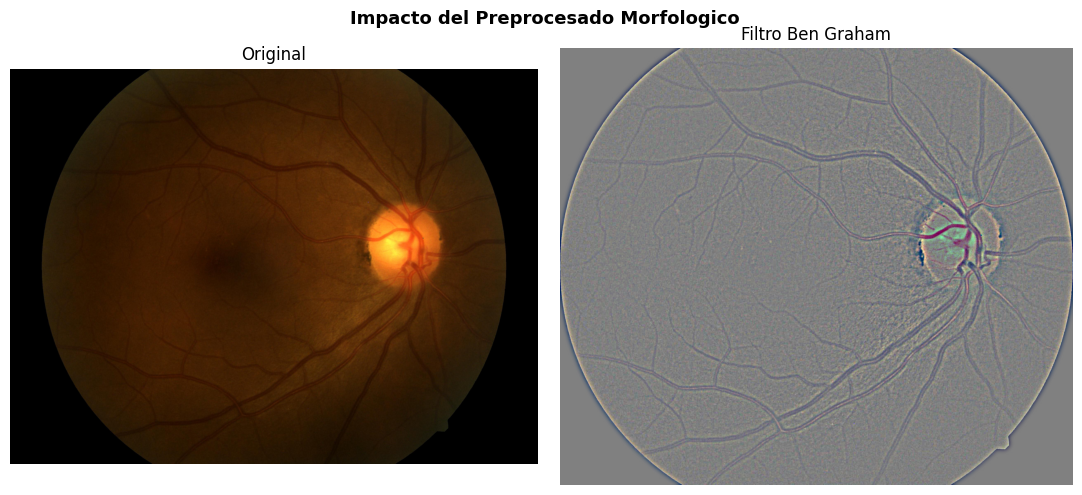

In [26]:
lista_fotos_procesadas = glob.glob(f"{CARPETA_NUEVA_TRAIN}/*/*.*") + glob.glob(
    f"{CARPETA_NUEVA_TEST}/*/*.*"
)

if lista_fotos_procesadas:
    foto_proc_ruta = random.choice(lista_fotos_procesadas)

    if CARPETA_NUEVA_TRAIN in foto_proc_ruta:
        foto_orig_ruta = foto_proc_ruta.replace(CARPETA_NUEVA_TRAIN, CARPETA_ORIGINAL_TRAIN)
    else:
        foto_orig_ruta = foto_proc_ruta.replace(CARPETA_NUEVA_TEST, CARPETA_ORIGINAL_TEST)

    img_orig = Image.open(foto_orig_ruta)
    img_proc = Image.open(foto_proc_ruta)

    fig, ax = plt.subplots(1, 2, figsize=(11, 5))
    ax[0].imshow(img_orig)
    ax[0].set_title("Original")
    ax[0].axis("off")
    ax[1].imshow(img_proc)
    ax[1].set_title("Filtro Ben Graham")
    ax[1].axis("off")
    plt.suptitle("Impacto del Preprocesado Morfologico", fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.show()
else:
    print("[AVISO] No se encontraron imagenes procesadas. Ejecuta la celda anterior primero.")

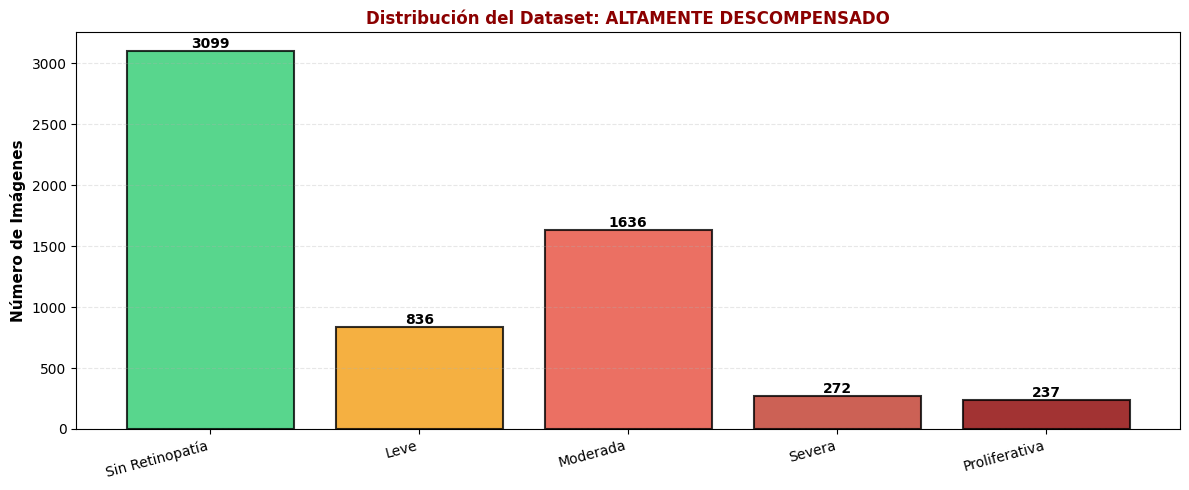

In [27]:
# Contar imágenes por clase y visualizar el desbalance
clases = ["0-noDR", "1-mild", "2-moderate", "3-severe", "4-proliferativeDR"]
nombres_clases = ["Sin Retinopatía", "Leve", "Moderada", "Severa", "Proliferativa"]
conteos_totales = {}

for clase in clases:
    train = len([f for f in os.listdir(os.path.join(CARPETA_NUEVA_TRAIN, clase)) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    test = len([f for f in os.listdir(os.path.join(CARPETA_NUEVA_TEST, clase)) if f.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp'))])
    conteos_totales[clase] = train + test

# Gráfica de distribución
fig, ax = plt.subplots(figsize=(12, 5))
valores = [conteos_totales[clase] for clase in clases]
colores_barras = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b', '#8b0000']
barras = ax.bar([nombres_clases[i] for i in range(len(clases))], valores, color=colores_barras, alpha=0.8, edgecolor='black', linewidth=1.5)

for barra, valor in zip(barras, valores):
    ax.text(barra.get_x() + barra.get_width()/2., barra.get_height(), f'{int(valor)}', 
            ha='center', va='bottom', fontweight='bold', fontsize=10)

ax.set_ylabel('Número de Imágenes', fontsize=11, fontweight='bold')
ax.set_title('Distribución del Dataset: ALTAMENTE DESCOMPENSADO', fontsize=12, fontweight='bold', color='darkred')
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

#### Problema: Dataset Muy Descompensado

El dataset tiene un severo desbalance de clases:
- Hay mucho más de unas clases que de otras
- El modelo tiende a predecir favorablemente la clase mayoritaria
- Consecuencia: Baja capacidad para diferenciar clases minoritarias
- El modelo puede tener una "ilusión de precisión" siendo malo en realidad

**Solución**: Usar técnicas de balanceo durante el entrenamiento (ponderación en loss, oversampling, etc.)

### 4.4. Comprobación del Impacto del Filtro (Entrenamiento Binario con Imágenes Procesadas)

#### 1. Carga de las fotografías filtradas y Data Augmentation

El orden correcto es **Resize primero** y luego aplicar las transformaciones de augmentation. Si no salen bandas negras en los lados.

Se añade `ColorJitter` al augmentation. Las retinografías tienen variaciones importantes de iluminación y contraste según el equipo y el paciente.

In [28]:
transformaciones_aug = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.1,
    ),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB),
])

transformaciones_test = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB),
])

# Cargamos train y test procesados ya separados (binario: Sano vs Enfermo)
dataset_train_proc = datasets.ImageFolder(
    root=CARPETA_NUEVA_TRAIN,
    target_transform=lambda c: 0 if c == 0 else 1,
)

dataset_test_proc = datasets.ImageFolder(
    root=CARPETA_NUEVA_TEST,
    target_transform=lambda c: 0 if c == 0 else 1,
)

print("[INFO] Dataset procesado detectado (ya separado):")
print(f"       Train: {len(dataset_train_proc)} fotos")
print(f"       Test : {len(dataset_test_proc)} fotos")
print(f"       Total: {len(dataset_train_proc) + len(dataset_test_proc)} fotos")

# Aplicamos transforms distintos a Train y Test (reutilizando la clase definida en Fase 1)
dataset_train_proc_aug = DatasetConTransform(dataset_train_proc, transformaciones_aug)
dataset_test_proc_st = DatasetConTransform(dataset_test_proc, transformaciones_test)

loader_train_proc = DataLoader(dataset_train_proc_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
loader_test_proc = DataLoader(dataset_test_proc_st, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("[INFO] DataLoaders procesados listos:")
print(f"       Train: {len(dataset_train_proc_aug)} fotos (con Augmentation)")
print(f"       Test : {len(dataset_test_proc_st)} fotos (limpio)")

[INFO] Dataset procesado detectado (ya separado):
       Train: 4864 fotos
       Test : 1216 fotos
       Total: 6080 fotos
[INFO] DataLoaders procesados listos:
       Train: 4864 fotos (con Augmentation)
       Test : 1216 fotos (limpio)


#### 2. Reinicio del Modelo Neuronal

Creamos una variable nueva `modelo_eff_proc` completamente limpia para no arrastrar ningún sesgo del entrenamiento anterior.

In [29]:
modelo_eff_proc = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

for parametro in modelo_eff_proc.parameters():
    parametro.requires_grad = False

neuronas_entrada = modelo_eff_proc.classifier[1].in_features
modelo_eff_proc.classifier[1] = nn.Linear(neuronas_entrada, NUM_CLASES)
modelo_eff_proc = modelo_eff_proc.to(device)

optimizador_eff_proc = optim.Adam(modelo_eff_proc.classifier[1].parameters(), lr=LEARNING_RATE)

print("[OK] EfficientNet-B0 reseteado y listo para recibir imágenes procesadas.")

[OK] EfficientNet-B0 reseteado y listo para recibir imágenes procesadas.


#### 3. Ejecutar el Entrenamiento de Verificación

In [30]:
print("-" * 60)
print("[ENTRENAMIENTO] Prueba: EfficientNet-B0 + Filtro Ben Graham")
print("-" * 60)

# Se crea un scheduler propio vinculado a optimizador_eff_proc
scheduler_eff_proc = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_eff_proc, mode='min', factor=0.5, patience=PACIENCIA_SCHEDULER, min_lr=1e-6)

modelo_eff_proc, historial_eff_proc = entrenar_modelo(
    modelo       = modelo_eff_proc,
    loader_train = loader_train_proc,
    loader_test  = loader_test_proc,
    criterion    = criterio_error,
    optimizer    = optimizador_eff_proc,
    num_epocas   = EPOCAS_PRUEBA,
    scheduler    = scheduler_eff_proc,
    patience     = PACIENCIA_EARLY_STOP
)

------------------------------------------------------------
[ENTRENAMIENTO] Prueba: EfficientNet-B0 + Filtro Ben Graham
------------------------------------------------------------
[INFO] Iniciando entrenamiento: 15 épocas | Paciencia ES: 6

[INFO] ÉPOCA 1 de 15
[TRAIN] Procesando 152 lotes...
   [>] Lote 5/152 (32 imgs) | Loss: 0.6869
   [>] Lote 10/152 (32 imgs) | Loss: 0.6844
   [>] Lote 15/152 (32 imgs) | Loss: 0.7236
   [>] Lote 20/152 (32 imgs) | Loss: 0.7348
   [>] Lote 25/152 (32 imgs) | Loss: 0.7019
   [>] Lote 30/152 (32 imgs) | Loss: 0.7254
   [>] Lote 35/152 (32 imgs) | Loss: 0.7054
   [>] Lote 40/152 (32 imgs) | Loss: 0.6670
   [>] Lote 45/152 (32 imgs) | Loss: 0.7136
   [>] Lote 50/152 (32 imgs) | Loss: 0.7558
   [>] Lote 55/152 (32 imgs) | Loss: 0.6869
   [>] Lote 60/152 (32 imgs) | Loss: 0.6764
   [>] Lote 65/152 (32 imgs) | Loss: 0.6935
   [>] Lote 70/152 (32 imgs) | Loss: 0.7284
   [>] Lote 75/152 (32 imgs) | Loss: 0.7047
   [>] Lote 80/152 (32 imgs) | Loss: 0.6751
 

### 4.5. Gráfica Comparativa (Sin Preprocesar vs Con Filtro Ben Graham)

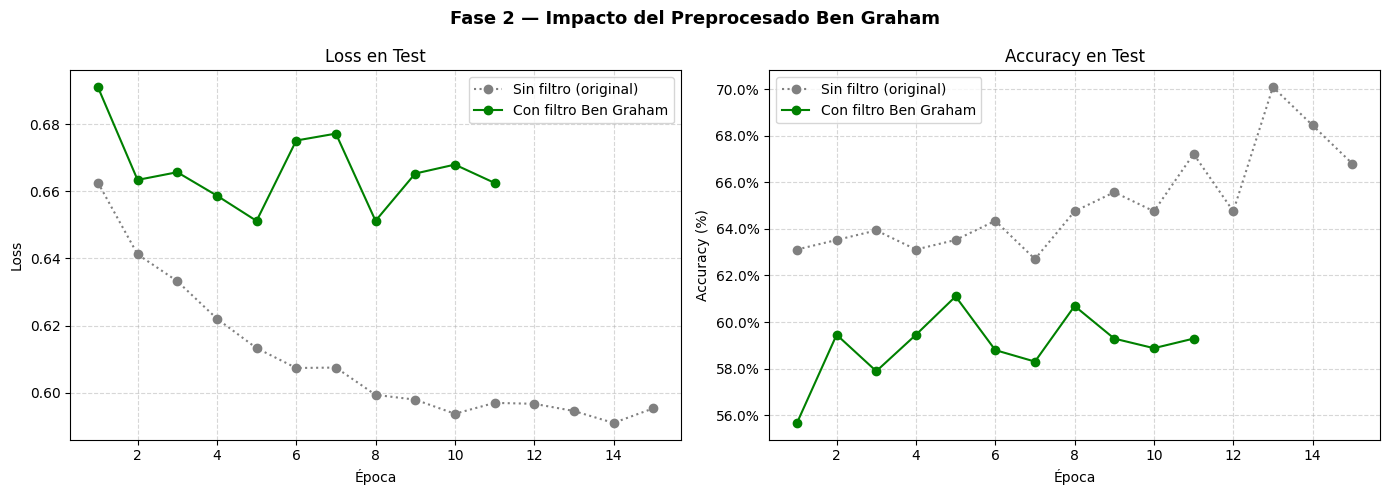


[RESUMEN] Mejor Test Acc sin filtro : 70.08%
[RESUMEN] Mejor Test Acc con filtro  : 61.10%


In [31]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

# [CORREGIDO] Usamos len() en lugar de EPOCAS_PRUEBA para manejar early stopping
epocas_base = range(1, len(historial_eff['test_acc']) + 1)
epocas_proc = range(1, len(historial_eff_proc['test_acc']) + 1)

axs[0].plot(epocas_base, historial_eff['test_loss'],      'o:', color='gray',  label='Sin filtro (original)')
axs[0].plot(epocas_proc, historial_eff_proc['test_loss'], 'o-', color='green', label='Con filtro Ben Graham')
axs[0].set_title("Loss en Test"); axs[0].set_xlabel("Época"); axs[0].set_ylabel("Loss")
axs[0].legend(); axs[0].grid(True, linestyle='--', alpha=0.5)

axs[1].plot(epocas_base, [a*100 for a in historial_eff['test_acc']],      'o:', color='gray',  label='Sin filtro (original)')
axs[1].plot(epocas_proc, [a*100 for a in historial_eff_proc['test_acc']], 'o-', color='green', label='Con filtro Ben Graham')
axs[1].yaxis.set_major_formatter(mtick.PercentFormatter())
axs[1].set_title("Accuracy en Test"); axs[1].set_xlabel("Época"); axs[1].set_ylabel("Accuracy (%)")
axs[1].legend(); axs[1].grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Fase 2 — Impacto del Preprocesado Ben Graham", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\n[RESUMEN] Mejor Test Acc sin filtro : {max(historial_eff['test_acc'])*100:.2f}%")
print(f"[RESUMEN] Mejor Test Acc con filtro  : {max(historial_eff_proc['test_acc'])*100:.2f}%")

## 5. FASE 3: Clasificador Multiclase de Degeneración (Puesta a Punto y Optimización)

Vamos a implementar nuestro modelo ganador (**EfficientNet-B0**) para clasificar las 5 categorías de retinopatía diabética:
- **Grado 0**: Sin retinopatía (Sano)
- **Grado 1**: Retinopatía Leve
- **Grado 2**: Retinopatía Moderada
- **Grado 3**: Retinopatía Severa
- **Grado 4**: Retinopatía Proliferativa (más grave)

En esta fase se introducen dos mejoras fundamentales respecto a la configuración anterior:

> **[NUEVO] Pesos de clase para dataset desbalanceado.** Los datasets de retinopatía tienen muchas más imágenes de grado 0 (sanos) que de grados 3-4 (casos graves). Sin corrección, la red aprende a predecir siempre las clases mayoritarias y tiene un accuracy artificialmente alto pero es inútil clínicamente. Los pesos inversamente proporcionales a la frecuencia de cada clase resuelven esto.

> **[NUEVO] Fine-tuning parcial.** En lugar de congelar toda la red y entrenar solo una capa lineal, descongelamos las últimas capas del extractor de características. Esto permite que EfficientNet adapte sus últimos filtros a los patrones específicos de las retinografías (microaneurismas, exudados, neovasos) que ImageNet nunca vio.

In [32]:
# ==========================================
# Hiperparámetros de la Fase 3
# ==========================================
NUM_CLASES_MULTI          = 5
EPOCAS_MULTI              = 20   # Más épocas: el fine-tuning necesita más tiempo para converger
PACIENCIA_EARLY_STOP_MULTI = 5   # [CORREGIDO] Antes era 10 = igual que épocas (inútil)
PACIENCIA_SCHEDULER_MULTI  = 3
LR_FINETUNE               = 1e-4 # LR más pequeño para las capas descongeladas
LR_CLASIFICADOR           = 1e-3 # LR normal para la nueva capa de clasificación

# ==========================================
# Transformaciones Multiclase
# [CORREGIDO] Resize PRIMERO — mismo orden correcto que en Fase 2
# [NUEVO] ColorJitter incluido
# ==========================================
transformaciones_aug_multi = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.1),        # [NUEVO] Volteo vertical (útil en retinografías)
    transforms.RandomRotation(degrees=20),        # ±20° para más variedad
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB)
])

transformaciones_test_multi = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN_RGB, std=STD_RGB)
])

print("[OK] Configuración de la Fase 3 cargada.")
print(f"     Épocas: {EPOCAS_MULTI} | Paciencia ES: {PACIENCIA_EARLY_STOP_MULTI} | LR fine-tune: {LR_FINETUNE}")

[OK] Configuración de la Fase 3 cargada.
     Épocas: 20 | Paciencia ES: 5 | LR fine-tune: 0.0001


### 5.1.1 Inspección y Carga del Dataset (Asegurando las 5 Categorías)

Cargamos por separado los conjuntos multiclase ya procesados (`train` y `test`) y verificamos que ambos tengan exactamente las mismas clases.

Además, revisamos la distribución de imágenes por clase para entender el desbalance del dataset.

In [33]:
CARPETA_MULTI_TRAIN = CARPETA_NUEVA_TRAIN
CARPETA_MULTI_TEST = CARPETA_NUEVA_TEST

dataset_multi_train = datasets.ImageFolder(root=CARPETA_MULTI_TRAIN)
dataset_multi_test = datasets.ImageFolder(root=CARPETA_MULTI_TEST)

if dataset_multi_train.classes != dataset_multi_test.classes:
    raise ValueError("Las clases de train y test no coinciden. Revisa las carpetas.")

# Se mantiene este alias para reutilizar celdas posteriores sin mas cambios
dataset_multi = dataset_multi_train

print("=" * 60)
print("[INFO] Dataset Multiclase (splits ya separados):")
print(f"       Train imágenes: {len(dataset_multi_train)}")
print(f"       Test imágenes : {len(dataset_multi_test)}")
print(f"       Total imágenes: {len(dataset_multi_train) + len(dataset_multi_test)}")
print(f"       Clases detectadas: {dataset_multi.classes}")
print("=" * 60)

# Contamos imágenes por clase (conteo global train+test)
conteo_clases = {c: 0 for c in dataset_multi.classes}
for _, clase_idx in dataset_multi_train.samples:
    conteo_clases[dataset_multi.classes[clase_idx]] += 1
for _, clase_idx in dataset_multi_test.samples:
    conteo_clases[dataset_multi.classes[clase_idx]] += 1

print("\n[INFO] Distribucion global de imagenes por clase (train+test):")
total_imgs = len(dataset_multi_train.samples) + len(dataset_multi_test.samples)
for nombre, cantidad in conteo_clases.items():
    barra = "█" * int(30 * cantidad / total_imgs)
    print(f"   {nombre:25s}: {cantidad:4d} imgs ({100*cantidad/total_imgs:.1f}%) {barra}")

# Pesos de clase calculados SOLO con train (evita mirar distribucion de test)
conteo_train_clases = {c: 0 for c in dataset_multi.classes}
for _, clase_idx in dataset_multi_train.samples:
    conteo_train_clases[dataset_multi.classes[clase_idx]] += 1

conteos_train_ordenados = [conteo_train_clases[c] for c in dataset_multi.classes]
total_train_imgs = len(dataset_multi_train.samples)
pesos_inversos = [total_train_imgs / (NUM_CLASES_MULTI * c) for c in conteos_train_ordenados]
pesos_tensor = torch.tensor(pesos_inversos, dtype=torch.float).to(device)

print("\n[NUEVO] Pesos de clase calculados sobre train:")
for clase, peso in zip(dataset_multi.classes, pesos_inversos):
    print(f"   {clase:25s}: peso = {peso:.3f}")

[INFO] Dataset Multiclase (splits ya separados):
       Train imágenes: 4864
       Test imágenes : 1216
       Total imágenes: 6080
       Clases detectadas: ['0-noDR', '1-mild', '2-moderate', '3-severe', '4-proliferativeDR']

[INFO] Distribucion global de imagenes por clase (train+test):
   0-noDR                   : 3099 imgs (51.0%) ███████████████
   1-mild                   :  836 imgs (13.8%) ████
   2-moderate               : 1636 imgs (26.9%) ████████
   3-severe                 :  272 imgs (4.5%) █
   4-proliferativeDR        :  237 imgs (3.9%) █

[NUEVO] Pesos de clase calculados sobre train:
   0-noDR                   : peso = 0.370
   1-mild                   : peso = 1.561
   2-moderate               : peso = 0.759
   3-severe                 : peso = 5.496
   4-proliferativeDR        : peso = 6.485


### 5.1.2 Carga de Splits y Asignación de Transformaciones (Data Augmentation)

En esta parte se aplican transformaciones de **augmentation** solo al conjunto de entrenamiento, mientras que el conjunto de test se mantiene limpio para evaluación objetiva.

In [34]:
# Usamos directamente train y test multiclase ya separados (sin random_split)
dataset_train_multi_aug = DatasetConTransform(dataset_multi_train, transformaciones_aug_multi)
dataset_test_multi_st = DatasetConTransform(dataset_multi_test, transformaciones_test_multi)

loader_train_multi = DataLoader(dataset_train_multi_aug, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
loader_test_multi = DataLoader(dataset_test_multi_st, batch_size=BATCH_SIZE, shuffle=False, num_workers=0)

print("[OK] Configuracion Multiclase completada:")
print(f"     Train : {len(dataset_multi_train)} fotos (con Augmentation + ColorJitter)")
print(f"     Test  : {len(dataset_multi_test)} fotos (limpio)")
print(f"     Total : {len(dataset_multi_train) + len(dataset_multi_test)} fotos")

[OK] Configuracion Multiclase completada:
     Train : 4864 fotos (con Augmentation + ColorJitter)
     Test  : 1216 fotos (limpio)
     Total : 6080 fotos


### 5.2. Instanciación del Modelo Multiclase con Fine-Tuning Parcial

> **[NUEVO] Fine-tuning parcial:** Descongelamos las últimas capas del bloque `features` de EfficientNet-B0 (concretamente los últimos 3 bloques MBConv). Estas capas aprenderán a detectar los patrones específicos de la retinopatía. Las primeras capas (que detectan bordes y texturas básicas) se mantienen congeladas para no perder el conocimiento de ImageNet con tan pocos datos.

In [35]:
# ==========================================
# 1. Cargar EfficientNet-B0 preentrenado
# ==========================================
modelo_multi = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

# 2. Congelar TODA la red inicialmente
for parametro in modelo_multi.parameters():
    parametro.requires_grad = False

# ==========================================
# [NUEVO] 3. Fine-tuning parcial: descongelar las últimas 3 capas del extractor
# EfficientNet-B0 tiene 9 bloques en features[1:9]. Descongelamos los 3 últimos.
# ==========================================
bloques_a_descongelar = list(modelo_multi.features.children())[-3:]
for bloque in bloques_a_descongelar:
    for parametro in bloque.parameters():
        parametro.requires_grad = True

params_descongelados = sum(p.numel() for p in modelo_multi.parameters() if p.requires_grad)
params_totales       = sum(p.numel() for p in modelo_multi.parameters())
print(f"[INFO] Parámetros descongelados para fine-tuning: {params_descongelados:,} de {params_totales:,} ({100*params_descongelados/params_totales:.1f}%)")

# 4. Reemplazar la capa final para 5 clases
neuronas_entrada = modelo_multi.classifier[1].in_features
modelo_multi.classifier[1] = nn.Linear(neuronas_entrada, NUM_CLASES_MULTI)
modelo_multi = modelo_multi.to(device)

# ==========================================
# [NUEVO] 5. Optimizador con diferentes learning rates por grupo de parámetros
# Las capas descongeladas reciben LR más pequeño (no queremos sobreescribir ImageNet)
# La nueva capa clasificadora recibe LR más alto (aprender desde cero)
# ==========================================
optimizador_multi = optim.Adam([
    {'params': [p for bloque in bloques_a_descongelar
                for p in bloque.parameters() if p.requires_grad],
     'lr': LR_FINETUNE},
    {'params': modelo_multi.classifier[1].parameters(),
     'lr': LR_CLASIFICADOR}
])

# [NUEVO] Criterio con pesos de clase para corregir el desbalance
criterio_ponderado = nn.CrossEntropyLoss(weight=pesos_tensor)

scheduler_multi = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizador_multi, mode='min', factor=0.3, patience=PACIENCIA_SCHEDULER_MULTI, min_lr=1e-7)

print(f"\n[STATUS] Modelo multiclase configurado:")
print(f"         Clases        : {NUM_CLASES_MULTI}")
print(f"         LR fine-tune  : {LR_FINETUNE}")
print(f"         LR clasificador: {LR_CLASIFICADOR}")
print(f"         Loss ponderada : Sí (corrige desbalance)")

[INFO] Parámetros descongelados para fine-tuning: 3,155,740 de 5,288,548 (59.7%)

[STATUS] Modelo multiclase configurado:
         Clases        : 5
         LR fine-tune  : 0.0001
         LR clasificador: 0.001
         Loss ponderada : Sí (corrige desbalance)


### 5.3. Entrenamiento Multiclase Final

In [36]:
print("\n" + "=" * 70)
print(f"   [INICIO] ENTRENAMIENTO MULTICLASE ({NUM_CLASES_MULTI} CLASES) CON FINE-TUNING")
print("=" * 70 + "\n")

# [NUEVO] Usamos criterio_ponderado (con pesos de clase) en lugar de criterio_error
modelo_multi, historial_multi = entrenar_modelo(
    modelo       = modelo_multi,
    loader_train = loader_train_multi,
    loader_test  = loader_test_multi,
    criterion    = criterio_ponderado,
    optimizer    = optimizador_multi,
    num_epocas   = EPOCAS_MULTI,
    scheduler    = scheduler_multi,
    patience     = PACIENCIA_EARLY_STOP_MULTI
)


   [INICIO] ENTRENAMIENTO MULTICLASE (5 CLASES) CON FINE-TUNING

[INFO] Iniciando entrenamiento: 20 épocas | Paciencia ES: 5

[INFO] ÉPOCA 1 de 20
[TRAIN] Procesando 152 lotes...
   [>] Lote 5/152 (32 imgs) | Loss: 1.6794
   [>] Lote 10/152 (32 imgs) | Loss: 1.5457
   [>] Lote 15/152 (32 imgs) | Loss: 1.4360
   [>] Lote 20/152 (32 imgs) | Loss: 1.5574
   [>] Lote 25/152 (32 imgs) | Loss: 1.6314
   [>] Lote 30/152 (32 imgs) | Loss: 1.5763
   [>] Lote 35/152 (32 imgs) | Loss: 1.5232
   [>] Lote 40/152 (32 imgs) | Loss: 1.5542
   [>] Lote 45/152 (32 imgs) | Loss: 1.5316
   [>] Lote 50/152 (32 imgs) | Loss: 1.7619
   [>] Lote 55/152 (32 imgs) | Loss: 1.3595
   [>] Lote 60/152 (32 imgs) | Loss: 1.6210
   [>] Lote 65/152 (32 imgs) | Loss: 1.4488
   [>] Lote 70/152 (32 imgs) | Loss: 1.8105
   [>] Lote 75/152 (32 imgs) | Loss: 1.4401
   [>] Lote 80/152 (32 imgs) | Loss: 1.2493
   [>] Lote 85/152 (32 imgs) | Loss: 1.1210
   [>] Lote 90/152 (32 imgs) | Loss: 1.4959
   [>] Lote 95/152 (32 imgs) 

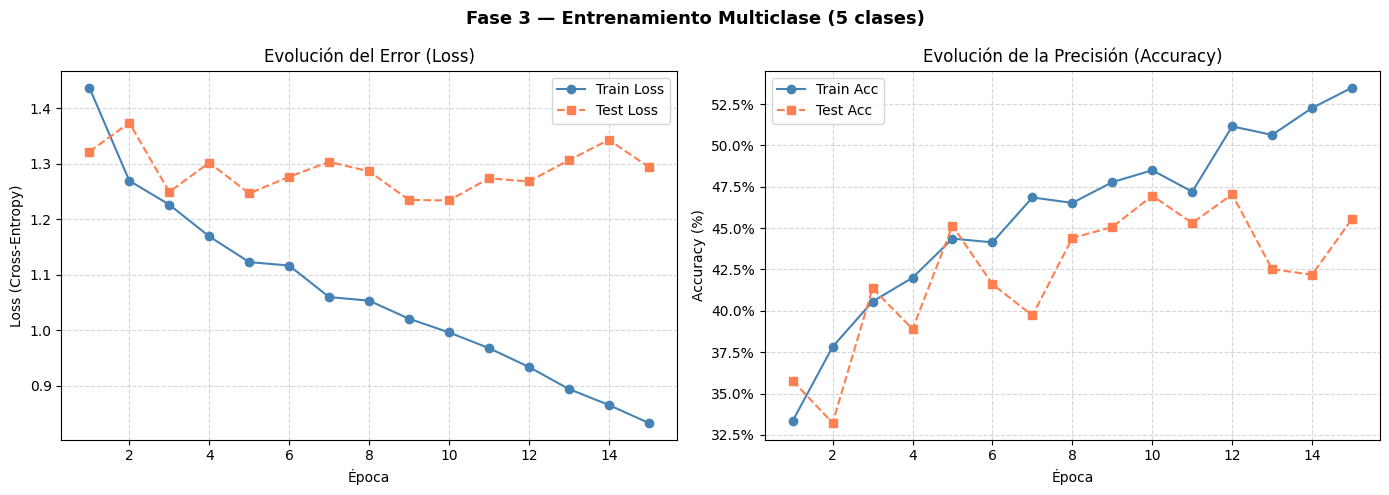

In [37]:
# Gráfica completa del entrenamiento multiclase
graficar_historial(historial_multi, titulo="Fase 3 — Entrenamiento Multiclase (5 clases)")

## 6. FASE 4: Resultados Finales y Evaluación Médica

A diferencia de las fases anteriores donde usábamos solo Accuracy como métrica, en esta fase desplegamos una **evaluación médica completa**. En un contexto clínico, no basta con saber que el modelo acierta el X% de las veces: necesitamos saber **qué tipo de errores comete**.

En retinopatía diabética, no diagnosticar a un paciente grave (falso negativo) es mucho peor que sobre-diagnosticar a uno sano (falso positivo).

Se generarán:
1. **Matriz de confusión**: muestra qué clases se confunden entre sí.
2. **Informe de clasificación completo**: Precision, Recall y F1-Score por cada grado de la enfermedad.

[INFO] Evaluando el modelo multiclase en el conjunto de Test...
[RESULTADO FINAL] Accuracy en Test: 46.96%

[MÉTRICAS POR CLASE]
                   precision    recall  f1-score   support

           0-noDR      0.533     0.737     0.618       467
           1-mild      0.303     0.094     0.143       213
       2-moderate      0.449     0.308     0.365       354
         3-severe      0.295     0.400     0.339        95
4-proliferativeDR      0.455     0.690     0.548        87

         accuracy                          0.470      1216
        macro avg      0.407     0.446     0.403      1216
     weighted avg      0.444     0.470     0.435      1216



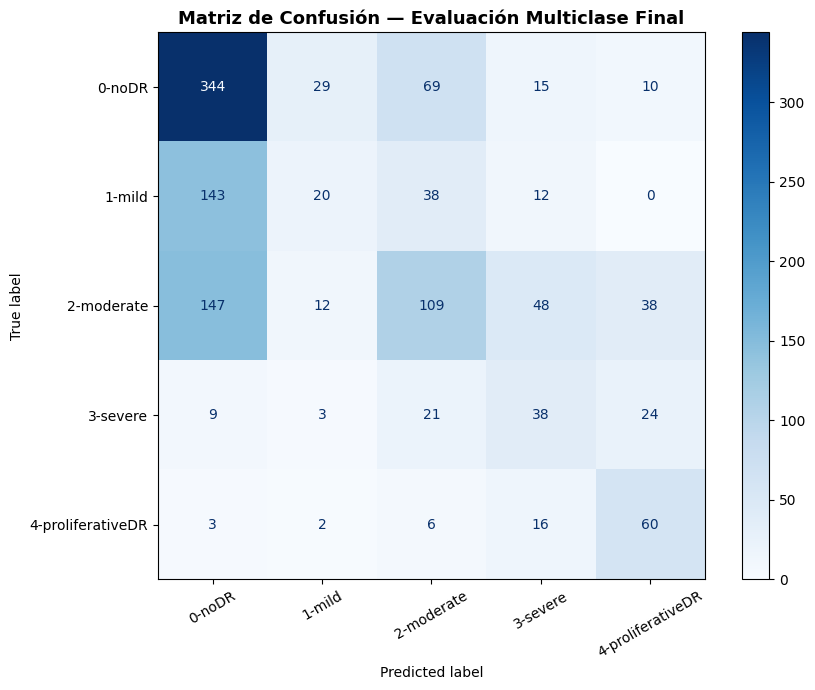


[MÉTRICAS GLOBALES]
   F1-Score Macro     : 0.4028  (media sin ponderar por clase)
   F1-Score Ponderado : 0.4345  (media ponderada por nº de muestras)

   → El F1-Macro es la métrica más relevante en datasets desbalanceados.
   → Un F1-Macro alto significa que el modelo funciona bien en TODAS las clases,
     incluidas las minoritarias (grados 3 y 4, los más graves).


In [38]:
def evaluar_modelo_completo(modelo, loader_test, device, nombres_clases):
    """
    [NUEVO] Evaluación completa: recoge todas las predicciones y etiquetas reales
    del conjunto de Test para calcular métricas avanzadas.
    """
    modelo.eval()
    todas_predicciones = []
    todas_etiquetas    = []

    with torch.no_grad():
        for imagenes, etiquetas in loader_test:
            imagenes  = imagenes.to(device)
            salidas   = modelo(imagenes)
            _, preds  = torch.max(salidas, 1)
            todas_predicciones.extend(preds.cpu().numpy())
            todas_etiquetas.extend(etiquetas.numpy())

    todas_predicciones = np.array(todas_predicciones)
    todas_etiquetas    = np.array(todas_etiquetas)

    # ─── Accuracy total ───
    acc_total = np.mean(todas_predicciones == todas_etiquetas)
    print(f"{'='*60}")
    print(f"[RESULTADO FINAL] Accuracy en Test: {acc_total*100:.2f}%")
    print(f"{'='*60}\n")

    # ─── Informe de clasificación por clase ───
    print("[MÉTRICAS POR CLASE]")
    print(classification_report(
        todas_etiquetas,
        todas_predicciones,
        target_names=nombres_clases,
        digits=3
    ))

    # ─── Matriz de confusión ───
    cm = confusion_matrix(todas_etiquetas, todas_predicciones)
    fig, ax = plt.subplots(figsize=(9, 7))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=30)
    ax.set_title("Matriz de Confusión — Evaluación Multiclase Final", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    # ─── F1-Score macro (métrica principal para datasets desbalanceados) ───
    f1_macro = f1_score(todas_etiquetas, todas_predicciones, average='macro')
    f1_pond  = f1_score(todas_etiquetas, todas_predicciones, average='weighted')
    print(f"\n[MÉTRICAS GLOBALES]")
    print(f"   F1-Score Macro     : {f1_macro:.4f}  (media sin ponderar por clase)")
    print(f"   F1-Score Ponderado : {f1_pond:.4f}  (media ponderada por nº de muestras)")
    print("\n   → El F1-Macro es la métrica más relevante en datasets desbalanceados.")
    print("   → Un F1-Macro alto significa que el modelo funciona bien en TODAS las clases,")
    print("     incluidas las minoritarias (grados 3 y 4, los más graves).")

    return todas_predicciones, todas_etiquetas


# Ejecutamos la evaluación completa
print("[INFO] Evaluando el modelo multiclase en el conjunto de Test...")
preds, labels = evaluar_modelo_completo(
    modelo_multi,
    loader_test_multi,
    device,
    dataset_multi.classes
)

In [39]:
# ==========================================
# [NUEVO] Análisis de los errores más frecuentes
# ==========================================
print("\n[ANÁLISIS DE ERRORES]")
print("Pares (Real → Predicho) más frecuentes cuando el modelo falla:\n")

errores = [(labels[i], preds[i]) for i in range(len(labels)) if labels[i] != preds[i]]
from collections import Counter
top_errores = Counter(errores).most_common(10)

for (real, pred), cuenta in top_errores:
    clase_real = dataset_multi.classes[real]
    clase_pred = dataset_multi.classes[pred]
    print(f"   {clase_real:25s} → {clase_pred:25s} : {cuenta} veces")

print(f"\n   Total de errores: {len(errores)} de {len(labels)} imágenes de Test ({100*len(errores)/len(labels):.1f}%)")


[ANÁLISIS DE ERRORES]
Pares (Real → Predicho) más frecuentes cuando el modelo falla:

   2-moderate                → 0-noDR                    : 147 veces
   1-mild                    → 0-noDR                    : 143 veces
   0-noDR                    → 2-moderate                : 69 veces
   2-moderate                → 3-severe                  : 48 veces
   1-mild                    → 2-moderate                : 38 veces
   2-moderate                → 4-proliferativeDR         : 38 veces
   0-noDR                    → 1-mild                    : 29 veces
   3-severe                  → 4-proliferativeDR         : 24 veces
   3-severe                  → 2-moderate                : 21 veces
   4-proliferativeDR         → 3-severe                  : 16 veces

   Total de errores: 645 de 1216 imágenes de Test (53.0%)


In [40]:
# ==========================================
# [NUEVO] Guardar el modelo final en disco
# ==========================================
RUTA_GUARDADO = "modelo_retinopatia_final.pth"

torch.save({
    'model_state_dict':     modelo_multi.state_dict(),
    'optimizer_state_dict': optimizador_multi.state_dict(),
    'clases':               dataset_multi.classes,
    'num_clases':           NUM_CLASES_MULTI,
    'img_size':             IMG_SIZE,
    'mejor_test_acc':       max(historial_multi['test_acc']),
    'mejor_test_loss':      min(historial_multi['test_loss']),
    'epocas_entrenadas':    len(historial_multi['train_loss']),
}, RUTA_GUARDADO)

print(f"[OK] Modelo guardado en: {RUTA_GUARDADO}")
print(f"     Mejor Test Accuracy: {max(historial_multi['test_acc'])*100:.2f}%")
print(f"     Épocas entrenadas  : {len(historial_multi['train_loss'])}")
print("\n[INFO] Para cargar el modelo en el futuro:")
print("    checkpoint = torch.load('modelo_retinopatia_final.pth')")
print("    modelo.load_state_dict(checkpoint['model_state_dict'])")

[OK] Modelo guardado en: modelo_retinopatia_final.pth
     Mejor Test Accuracy: 47.04%
     Épocas entrenadas  : 15

[INFO] Para cargar el modelo en el futuro:
    checkpoint = torch.load('modelo_retinopatia_final.pth')
    modelo.load_state_dict(checkpoint['model_state_dict'])


[OK] Modelo cargado desde: modelo_retinopatia_final.pth
[OK] Clases checkpoint: ['0-noDR', '1-mild', '2-moderate', '3-severe', '4-proliferativeDR']
[OK] Test cargado desde: fotos_procesadas_test
[OK] Clases test: ['0-noDR', '1-mild', '2-moderate', '3-severe', '4-proliferativeDR']


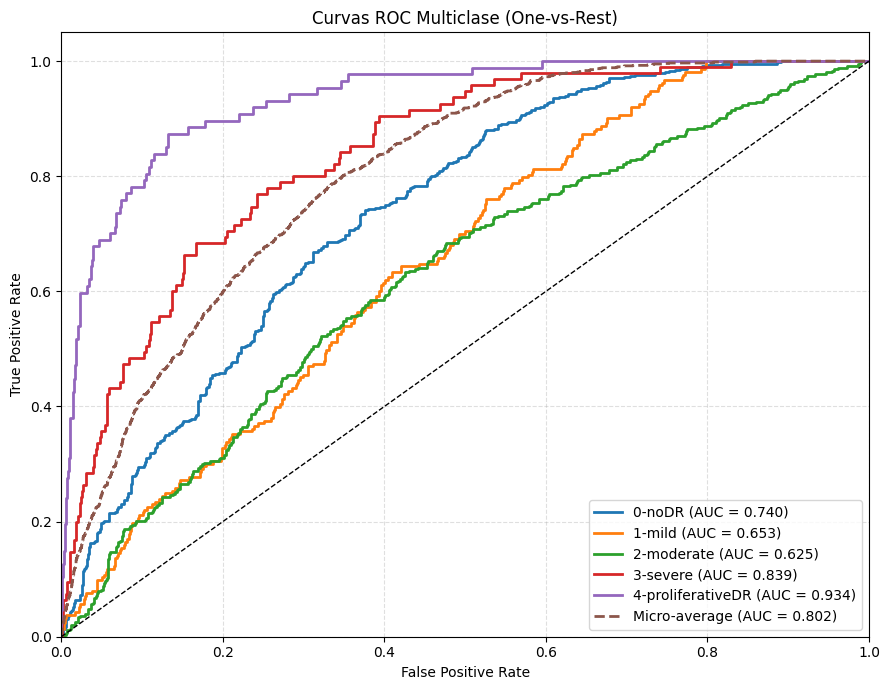

In [11]:
# === Celda autocontenida: carga modelo + construye test loader + ROC multiclase ===

import os
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# 0) Configuración mínima (ajusta TEST_DIR si no existe variable previa en el notebook)
RUTA_GUARDADO = "modelo_retinopatia_final.pth"
TEST_DIR = globals().get("CARPETA_NUEVA_TEST", globals().get("CARPETA_MULTI_TEST", None))
if TEST_DIR is None:
    TEST_DIR = "fotos_procesadas_test"  # <-- CAMBIA ESTO si no tienes CARPETA_NUEVA_TEST/CARPETA_MULTI_TEST

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# 1) Cargar checkpoint y reconstruir modelo
checkpoint = torch.load(RUTA_GUARDADO, map_location=device)

clases_ckpt = checkpoint["clases"]
num_clases_ckpt = checkpoint["num_clases"]
img_size_ckpt = checkpoint.get("img_size", 224)

modelo_cargado = models.efficientnet_b0(weights=None)
in_features = modelo_cargado.classifier[1].in_features
modelo_cargado.classifier[1] = nn.Linear(in_features, num_clases_ckpt)
modelo_cargado.load_state_dict(checkpoint["model_state_dict"])
modelo_cargado = modelo_cargado.to(device)
modelo_cargado.eval()

print(f"[OK] Modelo cargado desde: {RUTA_GUARDADO}")
print(f"[OK] Clases checkpoint: {clases_ckpt}")

# 2) Construir dataset/loader de test en esta misma celda
if not os.path.isdir(TEST_DIR):
    raise FileNotFoundError(f"No existe TEST_DIR: {TEST_DIR}")

mean_rgb = globals().get("MEAN_RGB", [0.485, 0.456, 0.406])
std_rgb  = globals().get("STD_RGB",  [0.229, 0.224, 0.225])

transform_test = transforms.Compose([
    transforms.Resize((img_size_ckpt, img_size_ckpt)),
    transforms.ToTensor(),
    transforms.Normalize(mean=mean_rgb, std=std_rgb)
])

dataset_test = datasets.ImageFolder(root=TEST_DIR, transform=transform_test)
loader_test_multi = DataLoader(dataset_test, batch_size=32, shuffle=False, num_workers=0)

# Validar/mapeo de índices de clases dataset -> checkpoint
faltantes = [c for c in dataset_test.classes if c not in clases_ckpt]
if faltantes:
    raise ValueError(f"Clases de test no presentes en checkpoint: {faltantes}")

idx_dataset_a_idx_ckpt = {
    dataset_test.class_to_idx[c]: clases_ckpt.index(c) for c in dataset_test.classes
}

print(f"[OK] Test cargado desde: {TEST_DIR}")
print(f"[OK] Clases test: {dataset_test.classes}")

# 3) Obtener y_true / y_score
y_true, y_score = [], []

with torch.no_grad():
    for imagenes, etiquetas in loader_test_multi:
        imagenes = imagenes.to(device)
        logits = modelo_cargado(imagenes)
        probs = torch.softmax(logits, dim=1).cpu().numpy()

        etiquetas_ckpt = [idx_dataset_a_idx_ckpt[int(e)] for e in etiquetas.numpy()]
        y_true.extend(etiquetas_ckpt)
        y_score.extend(probs)

y_true = np.array(y_true)
y_score = np.array(y_score)

# 4) ROC multiclase (OvR)
y_true_bin = label_binarize(y_true, classes=np.arange(num_clases_ckpt))

fpr, tpr, roc_auc = {}, {}, {}
for i in range(num_clases_ckpt):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_score[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

fpr["micro"], tpr["micro"], _ = roc_curve(y_true_bin.ravel(), y_score.ravel())
roc_auc["micro"] = auc(fpr["micro"], tpr["micro"])

# 5) Graficar
plt.figure(figsize=(9, 7))
for i, nombre_clase in enumerate(clases_ckpt):
    plt.plot(fpr[i], tpr[i], lw=2, label=f"{nombre_clase} (AUC = {roc_auc[i]:.3f})")

plt.plot(
    fpr["micro"], tpr["micro"], linestyle="--", lw=2,
    label=f"Micro-average (AUC = {roc_auc['micro']:.3f})"
)

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlim([0.0, 1.0]); plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Curvas ROC Multiclase (One-vs-Rest)")
plt.legend(loc="lower right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()